In [4]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
from IPython.display import HTML
from IPython.display import display

## Load Data

In [5]:
pres_debate_path = 'pres_debate.mp4'
video_html = f"""
<video width="640" height="480" controls>
  <source src="{pres_debate_path}" type="video/mp4">
  Your browser does not support the video tag.
</video>
"""
HTML(video_html)

In [6]:
def display_video(mp4_video_path: str) -> None:
    video_html = f"""
    <video width="640" height="480" controls>
      <source src="{mp4_video_path}" type="video/mp4">
      Your browser does not support the video tag.
    </video>
    """
    display(HTML(video_html))


def save_video_to_mp4(video_cap: cv2.VideoCapture, video_output_path: str) -> None:
    fourcc = cv2.VideoWriter_fourcc(*'H264')
    frame_width = int(video_cap.get(3))
    frame_height = int(video_cap.get(4))
    fps = video_cap.get(cv2.CAP_PROP_FPS)  # Get the original frame rate
    out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

    while video_cap.isOpened():
        ret, frame = video_cap.read()
        if not ret:
            break
        out.write(frame)
    video_cap.release()
    out.release()
    cv2.destroyAllWindows()

def save_video_to_mp4_by_frames(frames: list, video_output_path: str, fps: int = 30) -> None:
    fourcc = cv2.VideoWriter_fourcc(*'H264')
    frame_height, frame_width = frames[0].shape[:2]
    out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

    for frame in frames:
        out.write(frame)
    out.release()
    cv2.destroyAllWindows()

In [7]:
cap = cv2.VideoCapture(pres_debate_path)
save_video_to_mp4(cap, 'pres_debate_output.mp4')

OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [8]:
display_video('pres_debate_output.mp4')

In [9]:
pres_debate_bbox = 'pres_debate.txt'
with open(pres_debate_bbox, 'r') as f:
    lines = f.readlines()
    point_strings = lines[0].split()
    top_left_point = (float(point_strings[0]), float(point_strings[1]))
    h_w_strings = lines[1].split()
    w, h = float(h_w_strings[0]), float(h_w_strings[1])
top_left_point, h, w

((320.8751, 175.1776), 129.0504, 103.5404)

In [10]:
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
h = int(h)
w = int(w)

In [11]:
def draw_bbox(frame, top_left_point, h, w):
    bottom_right_point = top_left_point + np.array([h, w])
    cv2.rectangle(frame, tuple(top_left_point), tuple(bottom_right_point), (0, 255, 0), 2)
    return frame

def draw_bbox_from_center_point(frame, center_point, h, w):
    x_center, y_center = center_point
    x1 = int(x_center - w // 2)
    y1 = int(y_center - h // 2)
    x2 = int(x_center + w // 2)
    y2 = int(y_center + h // 2)

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return frame

In [12]:
frames = []
cap = cv2.VideoCapture(pres_debate_path)
fps = cap.get(cv2.CAP_PROP_FPS)
while cap.isOpened():
    ret, gray = cap.read()
    if not ret:
        break
    gray = draw_bbox(gray, top_left_point, h, w)
    frames.append(gray)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_bbox.mp4', fps)

OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [13]:
display_video('pres_debate_output_bbox.mp4')

In [14]:
cap = cv2.VideoCapture(pres_debate_path)

In [15]:
def init_particles(center_point_bbox, N=500, spread=20) -> np.ndarray:
    weights = np.ones((N), dtype=np.float64) / N
    particles = np.random.normal(center_point_bbox, spread, (N, 2))
    return particles, weights


def predict(particles: np.ndarray, mu=0, sigma=2) -> np.ndarray:
    N = particles.shape[0]
    # multinormal_noise = np.random.multivariate_normal(
    #     mean=[mu, mu], cov=(sigma ** 2) * np.eye(2), size=N)
    noise_x = np.random.normal(mu, sigma, N)
    noise_y = np.random.normal(mu, sigma, N)
    particles[:, 0] += noise_x
    particles[:, 1] += noise_y
    return particles


def mse(particle, template, h, w, frame) -> float:
    u, v = int(particle[0]), int(particle[1])
    if (v - h // 2 < 0 or v + h // 2 >= frame.shape[0] or
            u - w // 2 < 0 or u + w // 2 >= frame.shape[1]):
        return np.inf
    patch = frame[v - h // 2: v + h // 2, u - w // 2: u + w // 2]
    return np.mean((patch.astype(np.float64) - template.astype(np.float64)) ** 2)


def draw_particles(frame, particles):
    for particle in particles.astype(np.int32):
        cv2.circle(frame, tuple(particle), 1, (0, 0, 255), -1)
    return frame


def resample(particles: np.ndarray, weights: np.ndarray) -> np.ndarray:
    N = particles.shape[0]
    indices = np.random.choice(N, size=N, p=weights)
    return particles[indices]


def update_weights(particles: np.ndarray, template: np.ndarray, h, w, frame, mse_sigma=5) -> np.ndarray:
    weights = np.zeros((particles.shape[0]), dtype=np.float64)
    for i, particle in enumerate(particles):
        weights[i] = np.exp(-mse(particle, template, h, w,
                            frame) / (2 * mse_sigma**2))
    # weights += 1e-10
    weights /= np.sum(weights)
    return weights


def particle_filter(cap, center_point_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=2):
    particles, weights = init_particles(center_point_bbox, N, spread)
    print('initial center: ', center_point_bbox)
    frames = []
    i = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if i == 0: 
            print('first frame')
            first_frame = frame.copy()
            first_center_point_bbox = center_point_bbox
            first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)  
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        template = first_gray[int(first_center_point_bbox[1] - h // 2): int(first_center_point_bbox[1] + h // 2),
                        int(first_center_point_bbox[0] - w // 2): int(first_center_point_bbox[0] + w // 2)]
        particles = predict(particles, sigma=sigma)
        weights = update_weights(particles, template, h, w, gray, mse_sigma)
        center_point_bbox = particles[np.argmax(weights)]
        particles = resample(particles, weights)
        frame = draw_particles(frame, particles)
        frame = draw_bbox_from_center_point(frame, center_point_bbox, h, w)
        frames.append(frame)
        i += 1
    return frames

In [16]:
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = particle_filter(cap, center_bbox, h, w, 100)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_particle_filter.mp4', fps)

initial center:  [371 239]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [17]:
display_video('pres_debate_output_particle_filter.mp4')

## Window Size Change

In [18]:
new_h, new_w = h // 4, w // 4
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([new_w, new_h]) // 2
frames = particle_filter(cap, center_bbox, new_h, new_w, 200)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_particle_filter_half.mp4', fps)

initial center:  [332 191]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [19]:
display_video('pres_debate_output_particle_filter_half.mp4')

In [20]:
new_h, new_w = h * 2, w * 2
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([new_w, new_h]) // 2
frames = particle_filter(cap, center_bbox, new_h, new_w, 700)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_particle_filter_double.mp4', fps)

initial center:  [423 304]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [21]:
display_video('pres_debate_output_particle_filter_double.mp4')

## Noisy Debate

In [22]:
noisy_debate_path = 'noisy_debate (1).avi'
cap = cv2.VideoCapture(noisy_debate_path)
save_video_to_mp4(cap, 'noisy_debate_output.mp4')

OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [23]:
noisy_debate_path = 'noisy_debate_output.mp4'
display_video('noisy_debate_output.mp4')

In [24]:
noisy_debate_txt = 'noisy_debate.txt'
with open(noisy_debate_txt, 'r') as f:
    lines = f.readlines()
    point_strings = lines[0].split()
    top_left_point = (float(point_strings[0]), float(point_strings[1]))
    h_w_strings = lines[1].split()
    w, h = float(h_w_strings[0]), float(h_w_strings[1])
h = int(h)
w = int(w)
top_left_point, h, w

((320.8751, 175.1776), 129, 103)

In [25]:
cap = cv2.VideoCapture(noisy_debate_path)
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = particle_filter(cap, center_bbox, h, w, 100)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'noisy_debate_output_particle_filter.mp4', fps)

initial center:  [371 239]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [26]:
display_video('noisy_debate_output_particle_filter.mp4')

## Track Hand

In [27]:
pres_debate_bbox = 'pres_debate_hand.txt'
with open(pres_debate_bbox, 'r') as f:
    lines = f.readlines()
    point_strings = lines[0].split()
    top_left_point = (float(point_strings[0]), float(point_strings[1]))
    h_w_strings = lines[1].split()
    w, h = float(h_w_strings[0]), float(h_w_strings[1])
top_left_point, h, w

((535.0, 390.0), 100.0, 70.0)

In [28]:
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
h = int(h)
w = int(w)

In [29]:
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = particle_filter(cap, center_bbox, h, w, N=1000, mse_sigma=6, spread=50, sigma=15)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_particle_filter_hand.mp4', fps)

initial center:  [570 440]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [30]:
display_video('pres_debate_output_particle_filter_hand.mp4')

In [31]:
def last_frame_particle_filter(cap, center_point_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=2):
    particles, weights = init_particles(center_point_bbox, N, spread)
    print('initial center: ', center_point_bbox)
    frames = []
    i = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if i == 0:
            print('first frame')
            previous_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            previous_gray = current_gray
            current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        template = previous_gray[int(center_point_bbox[1] - h // 2): int(center_point_bbox[1] + h // 2), 
                                 int(center_point_bbox[0] - w // 2): int(center_point_bbox[0] + w // 2)]
        particles = predict(particles, sigma=sigma)
        weights = update_weights(particles, template, h, w, current_gray, mse_sigma)
        center_point_bbox = particles[np.argmax(weights)]
        particles = resample(particles, weights)
        frame = draw_particles(frame, particles)
        frame = draw_bbox_from_center_point(frame, center_point_bbox, h, w)
        frames.append(frame)
        i += 1
    return frames

In [32]:
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = last_frame_particle_filter(cap, center_bbox, h, w, N=500, mse_sigma=10, spread=20, sigma=20)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_last_frame_particle_filter.mp4', fps)

initial center:  [570 440]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [33]:
display_video('pres_debate_output_last_frame_particle_filter.mp4')

## Mixed Template

In [34]:
def last_frame_particle_filter(cap, center_point_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=2, alpha=0.1):
    particles, weights = init_particles(center_point_bbox, N, spread)
    print('initial center: ', center_point_bbox)
    frames = []
    i = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if i == 0:
            print('first frame')
            previous_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            previous_template = previous_gray[int(center_point_bbox[1] - h // 2): int(center_point_bbox[1] + h // 2),
                                              int(center_point_bbox[0] - w // 2): int(center_point_bbox[0] + w // 2)]
            current_template = previous_template
            template = current_template
        else:
            previous_gray = current_gray
            current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            previous_template = current_template
            current_template = previous_gray[int(center_point_bbox[1] - h // 2): int(center_point_bbox[1] + h // 2),
                                             int(center_point_bbox[0] - w // 2): int(center_point_bbox[0] + w // 2)]
            template = alpha * current_template.astype(np.float64) + (
                1 - alpha) * previous_template.astype(np.float64)
        particles = predict(particles, sigma=sigma)
        weights = update_weights(
            particles, template, h, w, current_gray, mse_sigma)
        center_point_bbox = particles[np.argmax(weights)]
        particles = resample(particles, weights)
        frame = draw_particles(frame, particles)
        frame = draw_bbox_from_center_point(frame, center_point_bbox, h, w)
        frames.append(frame)
        i += 1
    return frames

In [35]:
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = last_frame_particle_filter(cap, center_bbox, h, w, N=500, mse_sigma=10, spread=20, sigma=20)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_last_frame_particle_filter_alpha.mp4', fps)

initial center:  [570 440]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [36]:
display_video('pres_debate_output_last_frame_particle_filter_alpha.mp4')

In [37]:
cap = cv2.VideoCapture(noisy_debate_path)
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = last_frame_particle_filter(cap, center_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=15, alpha=0.001)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'noisy_debate_output_last_frame_particle_filter_alpha.mp4', fps)

initial center:  [570 440]
first frame


OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [38]:
display_video('noisy_debate_output_last_frame_particle_filter_alpha.mp4')

In [39]:
pres_debate_bbox = 'pres_debate.txt'
with open(pres_debate_bbox, 'r') as f:
    lines = f.readlines()
    point_strings = lines[0].split()
    top_left_point = (float(point_strings[0]), float(point_strings[1]))
    h_w_strings = lines[1].split()
    w, h = float(h_w_strings[0]), float(h_w_strings[1])
top_left_point, h, w

((320.8751, 175.1776), 129.0504, 103.5404)

In [40]:
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
h = int(h)
w = int(w)

## Mean Shift

In [41]:
def build_histograms(patch: np.ndarray, bins=8):
    hist = np.zeros((bins, bins, bins), dtype=np.int32)
    bgr_scaled = ((patch / 255) * (bins - 1)).astype(np.int32)
    b, g, r = bgr_scaled[:, :, 0], bgr_scaled[:, :, 1], bgr_scaled[:, :, 2]
    np.add.at(hist, (b.flatten(), g.flatten(), r.flatten()), 1)
    return hist


def normalize_hist(hist: np.ndarray) -> np.ndarray:
    return hist / np.sum(hist)


def chi_squared(hist1: np.ndarray, hist2: np.ndarray) -> float:
    mask = (hist1 + hist2) > 0
    return 0.5 * np.sum((hist1[mask] - hist2[mask]) ** 2 / (hist1[mask] + hist2[mask] + 1e-10))


def update_weights(particles: np.ndarray, template: np.ndarray, h, w, frame, mse_sigma=5) -> np.ndarray:
    weights = np.zeros((particles.shape[0]), dtype=np.float64)
    template_hist = build_histograms(template.astype(np.int32))
    template_hist = normalize_hist(template_hist)
    for i, particle in enumerate(particles):
        u, v = int(particle[0]), int(particle[1])
        if (v - h // 2 < 0 or v + h // 2 >= frame.shape[0] or
                u - w // 2 < 0 or u + w // 2 >= frame.shape[1]):
            weights[i] = 0
            continue
        patch = frame[v - h // 2: v + h // 2, u - w // 2: u + w // 2]
        patch_hist = build_histograms(patch)
        patch_hist = normalize_hist(patch_hist)
        chi_square = chi_squared(patch_hist, template_hist)
        weights[i] = np.exp(-chi_square / (2 * mse_sigma**2))
    weights /= np.sum(weights)
    return weights


def chi_squared(hist1: np.ndarray, hist2: np.ndarray) -> float:
    mask = (hist1 + hist2) > 0
    return 0.5 * np.sum((hist1[mask] - hist2[mask]) ** 2 / (hist1[mask] + hist2[mask] + 1e-10))


def particle_filter_with_rgb(cap, center_point_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=2):
    particles, weights = init_particles(center_point_bbox, N, spread)
    print('initial center: ', center_point_bbox)
    frames = []
    i = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        if i == 0:
            print('first frame')
            first_frame = hsv_frame.copy()
            first_center_point_bbox = center_point_bbox
            template = first_frame[int(first_center_point_bbox[1] - h // 2): int(first_center_point_bbox[1] + h // 2),
                                   int(first_center_point_bbox[0] - w // 2): int(first_center_point_bbox[0] + w // 2)]
        particles = predict(particles, sigma=sigma)
        weights = update_weights(particles, template, h, w, hsv_frame, mse_sigma)
        # center_point_bbox = particles[np.argmax(weights)]
        center_point_bbox = np.average(particles, axis=0, weights=weights)
        particles = resample(particles, weights)
        frame = draw_particles(frame, particles, weights)
        frame = draw_bbox_from_center_point(frame, center_point_bbox, h, w)
        frames.append(frame)
        i += 1
    return frames

In [42]:
cap = cv2.VideoCapture(pres_debate_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = particle_filter_with_rgb(cap, center_bbox, h, w, N=400, mse_sigma=5, spread=20, sigma=8)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pres_debate_output_particle_filter_rgb.mp4', fps)

initial center:  [371 239]
first frame


TypeError: draw_particles() takes 2 positional arguments but 3 were given

In [387]:
display_video('pres_debate_output_particle_filter_rgb.mp4')

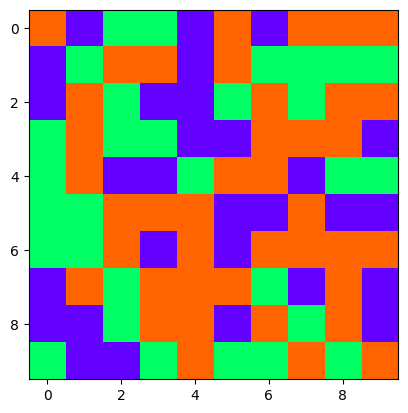

In [267]:
colors = [[255, 100, 0], [0, 255, 100], [100, 0, 255]]
patch = np.zeros((10, 10, 3), dtype=np.uint8)
for i in range(10):
    for j in range(10):
        patch[i, j] = colors[np.random.choice(len(colors))]
plt.imshow(patch)

In [379]:
hist = build_histograms(patch)
hist = normalize_hist(hist)
rotated_patch = np.rot90(patch, 1)
rotated_hist = build_histograms(rotated_patch)
rotated_hist = normalize_hist(rotated_hist)
chi_squared(hist, rotated_hist)

0.0

In [380]:
negative_patch = 255 - patch
negative_hist = build_histograms(negative_patch)
negative_hist = normalize_hist(negative_hist)

0.9999999997

## Pedestrians

In [43]:
pedestrians_path = 'pedestrians.avi'
cap = cv2.VideoCapture(pedestrians_path)
save_video_to_mp4(cap, 'pedestrians_output.mp4')

OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [44]:
display_video('pedestrians_output.mp4')

In [45]:
pedestrians_bbox = 'pedestrians.txt'
with open(pedestrians_bbox, 'r') as f:
    lines = f.readlines()
    point_strings = lines[0].split()
    top_left_point = (float(point_strings[0]), float(point_strings[1]))
    h_w_strings = lines[1].split()
    w, h = float(h_w_strings[0]), float(h_w_strings[1])
top_left_point, h, w

((211.0, 36.0), 293.0, 100.0)

In [46]:
top_left_point = np.array(top_left_point, dtype=np.int32)
top_left_x, top_left_y = top_left_point
h = int(h)
w = int(w)

In [68]:
def init_particles(center_point_bbox,  init_h, init_w, N=500, spread=20, box_size_spread=5):
    weights = np.ones((N), dtype=np.float64) / N
    particles = np.empty((N, 4))
    particles[:, 0] = np.random.normal(center_point_bbox[0], spread, N)
    particles[:, 1] = np.random.normal(center_point_bbox[1], spread, N)
    particles[:, 2] = np.random.normal(init_h, box_size_spread, N)
    particles[:, 3] = np.random.normal(init_w, box_size_spread, N)
    return particles, weights


def predict(particles, mu=0, sigma=5, box_size_sigma=5):
    N = particles.shape[0]
    cov_matrix = np.diag(
        [sigma ** 2, sigma ** 2, box_size_sigma ** 2, box_size_sigma ** 2])
    particles_noise = np.random.multivariate_normal(
        mean=[mu, mu, mu, mu], cov=cov_matrix, size=N)
    particles += particles_noise
    return particles

def mse(particle, template, h, w, frame) -> float:
    u, v = int(particle[0]), int(particle[1])
    if (v - h // 2 < 0 or v + h // 2 >= frame.shape[0] or
            u - w // 2 < 0 or u + w // 2 >= frame.shape[1]):
        return np.inf
    patch = frame[v - h // 2: v + h // 2, u - w // 2: u + w // 2]
    if patch.shape[0] == 0 or patch.shape[1] == 0:
        return np.inf
    new_template = cv2.resize(template, (patch.shape[1], patch.shape[0]))
    return np.mean((patch.astype(np.float64) - new_template.astype(np.float64)) ** 2)


def update_weights(particles: np.ndarray, template: np.ndarray, frame, mse_sigma=5) -> np.ndarray:
    weights = np.zeros((particles.shape[0]), dtype=np.float64)
    for i, particle in enumerate(particles):
        h = int(particle[2])
        w = int(particle[3])
        weights[i] = np.exp(-mse(particle, template, h, w,
                            frame) / (2 * mse_sigma**2))
    weights /= np.sum(weights)
    return weights

def draw_particles(frame, particles):
    for particle in particles.astype(np.int32):
        cv2.circle(frame, tuple([particle[0], particle[1]]), 1, (0, 0, 255), -1)
    return frame

def draw_bbox_from_center_point(frame, center_point, h, w):
    x_center, y_center = center_point
    x1 = int(x_center - w // 2)
    y1 = int(y_center - h // 2)
    x2 = int(x_center + w // 2)
    y2 = int(y_center + h // 2)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return frame

def particle_filter(cap, center_point_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=2):
    particles, weights = init_particles(center_point_bbox, h, w, N, spread)
    print('initial center: ', center_point_bbox)
    frames = []
    i = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if i == 0:
            print('first frame')
            first_frame = frame.copy()
            first_center_point_bbox = center_point_bbox
            first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
            init_h = h
            init_w = w
            template = first_gray[int(first_center_point_bbox[1] - init_h // 2): int(first_center_point_bbox[1] + init_h // 2),
                                  int(first_center_point_bbox[0] - init_w // 2): int(first_center_point_bbox[0] + init_w // 2)]
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        particles = predict(particles, sigma=sigma)
        weights = update_weights(particles, template, gray, mse_sigma)
        center_point_bbox_x, center_point_bbox_y, h, w = particles[np.argmax(weights)]
        center_point_bbox = np.array([center_point_bbox_x, center_point_bbox_y])
        print(f'center_point_bbox: {center_point_bbox}, h: {h}, w: {w}')
        particles = resample(particles, weights)
        frame = draw_particles(frame, particles)
        frame = draw_bbox_from_center_point(frame, center_point_bbox, h, w)
        frames.append(frame)
        i += 1
    return frames

In [69]:
cap = cv2.VideoCapture(pedestrians_path)
center_bbox = np.array([top_left_x, top_left_y]) + np.array([w, h]) // 2
frames = particle_filter(cap, center_bbox, h, w, N=500, mse_sigma=5, spread=20, sigma=1)
fps = cap.get(cv2.CAP_PROP_FPS)
save_video_to_mp4_by_frames(frames, 'pedestrians_output_last_frame_particle_filter_alpha.mp4', fps)

initial center:  [261 182]
first frame
center_point_bbox: [263.68175997 181.68539114], h: 295.3071570337221, w: 93.66277695465928
center_point_bbox: [262.70534207 181.96980233], h: 293.3096207390773, w: 101.65176889125607
center_point_bbox: [264.64826782 180.97801264], h: 292.09392154339224, w: 98.35403362994946
center_point_bbox: [265.29695909 179.87669024], h: 290.6535961372361, w: 96.50782986108
center_point_bbox: [266.54449315 178.77715086], h: 291.86061954963895, w: 94.139596214093
center_point_bbox: [267.9565416  177.23534098], h: 290.7582861065884, w: 95.191854043674
center_point_bbox: [269.12642098 177.67171458], h: 290.2927596246119, w: 91.53114552517268
center_point_bbox: [269.75343705 179.49504669], h: 280.0531539437878, w: 89.42348429561942
center_point_bbox: [270.67400633 182.0051694 ], h: 268.5838865817977, w: 87.7581775301058
center_point_bbox: [271.36631897 182.99066377], h: 265.32484886507916, w: 86.97890168477977
center_point_bbox: [271.04506893 182.11658867], h: 267.

OpenCV: FFMPEG: tag 0x34363248/'H264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'


In [70]:
display_video('pedestrians_output_last_frame_particle_filter_alpha.mp4')